# 07 · Candidate repricing policies  (Part 4)

The dynamic decision is **when to reprice** (and by how much), not "what is the
single optimal price". With demand inelastic and **no marginal-cost data**, the
constant-elasticity revenue function `RevPAR(P) = P₀Q₀(P/P₀)^{1+β}` is monotone
in P for β > −1 — so a revenue "optimum" just pins to whatever price ceiling is
imposed. We therefore **compare policies on the frequency / real-stability /
occupancy / revenue trade-off** (Pareto frontier in notebook 08), and never
claim a profit- or revenue-maximising price.

Policies (from `src/policies.py`):

| | rule |
|---|---|
| **P0** frozen nominal | price never changes → real-erosion reference |
| **P1** monthly CPI index | raise by last month's inflation every month |
| **P2** cumulative-inflation threshold τ | hold until CPI has risen ≥ τ since the last change, then reset to restore the real price |
| **P3** threshold τ + occupancy tilt δ | as P2, but scale the catch-up by trailing occupancy vs its seasonal norm (weak demand → partial pass-through) |

Every policy uses **information available at t−1 only** (INDEC releases month-t
CPI in mid-month t+1). Paths are anchored so each policy starts at the same
*real* level (the pre-COVID target), so the comparison is about timing, not the
starting price.

**Output** `outputs/tables/table_policy_example.csv`, `outputs/figures/07_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog
import policies as PL
import pricing_eval as EV

LOG = AuditLog("07_policies")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS).rename(columns={"infl_mom_gba_frac": "infl_mom"})
LAB = C.CATEGORY_LABELS
CATS = C.PRESENT_CATEGORIES

## 1 · Why the revenue optimum is degenerate (constant-elasticity demand)

`Q(P) = Q₀ (P/P₀)^β`.  RevPAR curve for 4★ over a ±40% price grid, several β.
For β > −1 it rises monotonically → the "optimal" pass-through sits at the grid
edge. Interior optimum needs marginal cost, which we do not have.

  [07_policies] figure                 07_revenue_curves.png                      
  [07_policies] degeneracy             |β|<1 → RevPAR monotone in P               no interior optimum without marginal cost → compare repricing rules, not a point


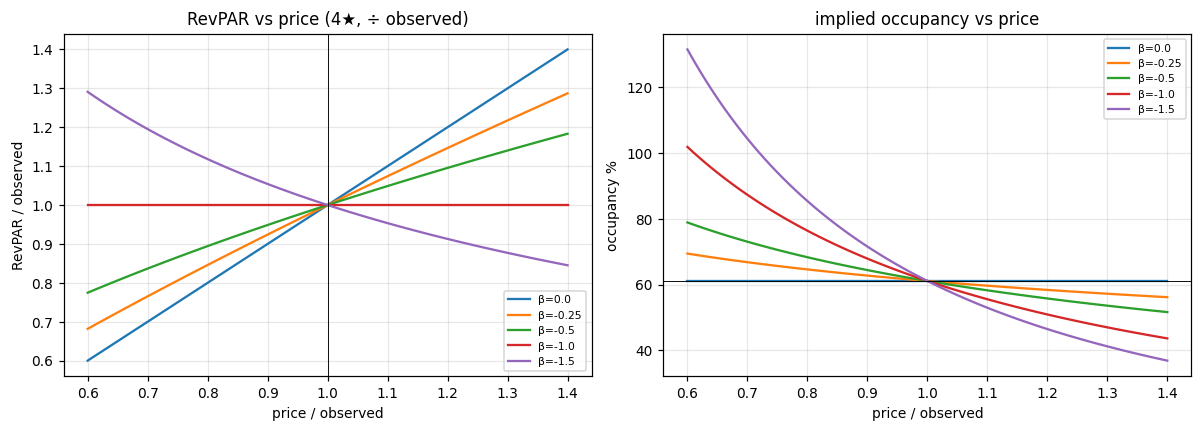

In [2]:
m = df[(df.hotel_category == "stars_4") & (df.split == "test")]
p0, q0 = m["average_rate"].median(), m["room_occupancy"].median() / 100
mult = np.linspace(0.6, 1.4, 81)
i1 = int(np.argmin(np.abs(mult - 1)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for b in C.BETA_SCENARIOS + [-1.5]:
    rev = (p0 * mult) * (q0 * mult ** b)
    ax[0].plot(mult, rev / rev[i1], label=f"β={b}")
    ax[1].plot(mult, q0 * mult ** b * 100, label=f"β={b}")
ax[0].axvline(1, color="k", lw=.6); ax[0].set_title("RevPAR vs price (4★, ÷ observed)")
ax[0].set_xlabel("price / observed"); ax[0].set_ylabel("RevPAR / observed"); ax[0].legend(fontsize=7)
ax[1].axhline(q0 * 100, color="k", lw=.6); ax[1].set_title("implied occupancy vs price")
ax[1].set_xlabel("price / observed"); ax[1].set_ylabel("occupancy %"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_revenue_curves.png")
LOG.log("figure", "07_revenue_curves.png")
LOG.log("degeneracy", "|β|<1 → RevPAR monotone in P",
        detail="no interior optimum without marginal cost → compare repricing rules, not a point")
plt.show()

## 2 · Worked example — 4★, test window (2024-01 … 2026-05)

τ = 5%, δ = 5% for illustration (notebook 08 selects them on validation).

In [3]:
cat = "stars_4"
s = df[df.hotel_category == cat].sort_values("date")
train = s[s.split == "train"]
occ_norm = PL.seasonal_occ_norm(train)
tgt = EV.target_real_rate(s)
pols = [PL.policy0_frozen(), PL.policy1_monthly_cpi(),
        PL.policy2_threshold(0.05), PL.policy3_threshold_occ(0.05, 0.05)]
paths = {p.name: PL.simulate(p, s, C.TEST_SEGMENT, occ_norm=occ_norm, anchor_real=tgt)
         for p in pols}
paths["observed"] = PL.observed_path(s, C.TEST_SEGMENT)

rows = []
for beta in C.BETA_SCENARIOS:
    for name, pth in paths.items():
        sc = EV.score(pth, beta=beta, target_real=tgt)
        rows.append(dict(policy=name, beta=beta, n_reprice=sc["n_reprice"],
                         real_dev_mean_pct=round(sc["real_dev_mean_pct"], 1),
                         real_dev_min_pct=round(sc["real_dev_min_pct"], 1),
                         real_P_cv_pct=round(sc["real_P_cv_pct"], 1),
                         mean_occ=round(sc["mean_occ"], 1),
                         revpar_vs_obs_pct=round(sc["revpar_vs_obs_pct"], 1)))
ex = pd.DataFrame(rows)
ex.to_csv(C.OUT_TAB / "table_policy_example.csv", index=False)
LOG.log("write", "table_policy_example.csv", len(ex))
ex[ex.beta == -0.5].set_index("policy")

  [07_policies] write                  table_policy_example.csv               20  


,beta,n_reprice,real_dev_mean_pct,real_dev_min_pct,real_P_cv_pct,mean_occ,revpar_vs_obs_pct
policy,,,,,,,
P0_frozen,-0.5,1,-53.5,-70.2,27.4,88.8,-32.4
P1_monthly_cpi,-0.5,25,-4.4,-16.4,3.8,60.6,1.0
P2_tau5,-0.5,13,-5.7,-16.4,3.6,61.0,0.3
P3_tau5_d5,-0.5,13,-6.7,-16.4,4.3,61.3,-0.2
observed,-0.5,25,-5.1,-17.3,11.3,60.7,0.0


## 3 · Illustrative price and real-price paths

  [07_policies] figure                 07_policy_paths_4star.png                  


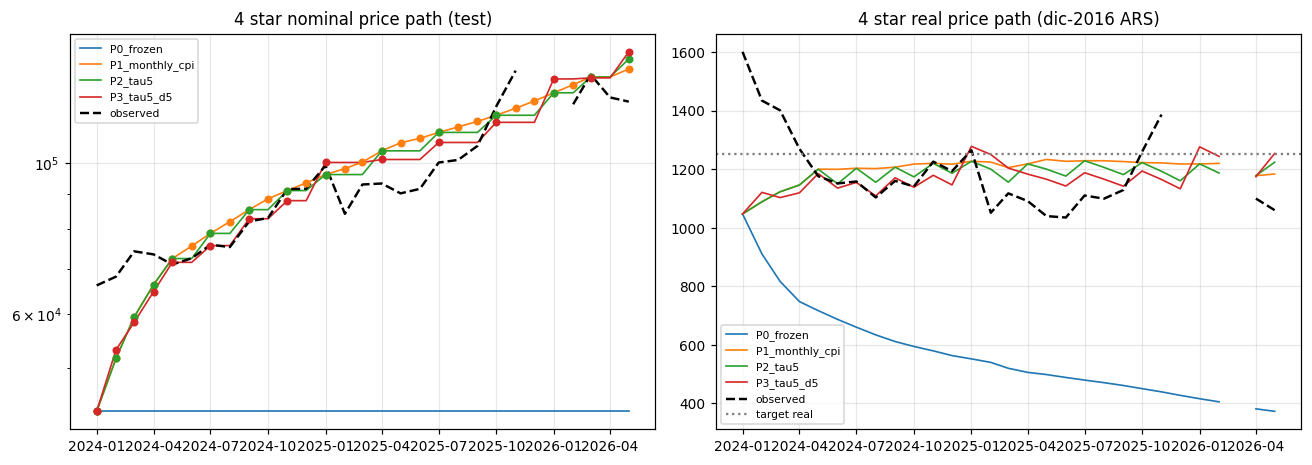

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for name, pth in paths.items():
    st = "k--" if name == "observed" else "-"
    lw = 1.6 if name == "observed" else 1.1
    ax[0].plot(pth.date, pth.P, st, lw=lw, label=name)
    ax[1].plot(pth.date, pth.real_P, st, lw=lw, label=name)
    if name.startswith("P") and "reprice" in pth:
        rp = pth[pth.reprice]
        ax[0].scatter(rp.date, rp.P, s=18, zorder=4)
ax[0].set_yscale("log"); ax[0].set_title(f"{LAB[cat]} nominal price path (test)"); ax[0].legend(fontsize=7)
ax[1].axhline(tgt, color="0.5", ls=":", label="target real")
ax[1].set_title(f"{LAB[cat]} real price path (dic-2016 ARS)"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_policy_paths_4star.png")
LOG.log("figure", "07_policy_paths_4star.png"); plt.show()

In [5]:
LOG.flush()
print("07 complete.")

07 complete.
